<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h1>LogisticRegression</h1>
    <h1>PCA + LogisticRegression + GridSearchCV</h1>
<hr>
</div>

In [27]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score

In [28]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [30]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [31]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [34]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']),    
    # ], remainder=MinMaxScaler()
    ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', MinMaxScaler())
        ])  
)

In [35]:
X_train = transformer.fit_transform(X_train)

In [36]:
X_test = transformer.transform(X_test)

In [37]:
X_test.shape

(51070, 51)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. PCA</h2>
</div>

In [38]:
from sklearn.decomposition import PCA

In [39]:
pca = PCA()

In [40]:
X_pca = pca.fit_transform(X_train)

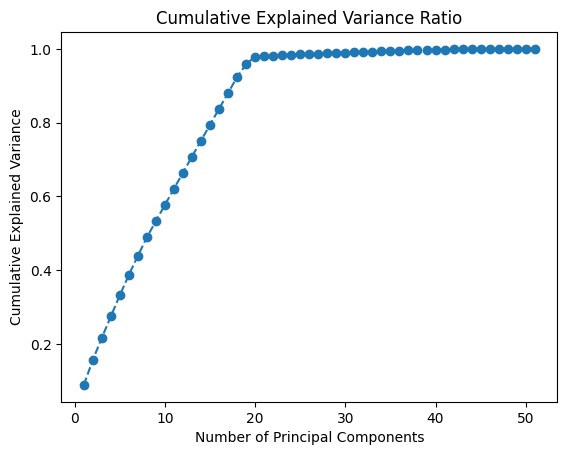

In [41]:
# Plot explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o' , linestyle='--')
plt.title('Cumulative Explained Variance Ratio') 
plt.xlabel('Number of Principal Components') 
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [42]:
# Determine the optimal number of components based on the explained variance
n_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to retain 95% variance: {n_components}")

Number of components to retain 95% variance: 19


<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>4. LogisticRegression</h2>
</div>

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
classifier = Pipeline([
    ('pca', PCA(n_components=n_components)),  # Reduce dimensions using PCA
    ('classifier', LogisticRegression(C = 0.01, random_state = 42))
])

In [45]:
classifier.fit(X_train,y_train)

Pipeline(steps=[('pca', PCA(n_components=19)),
                ('classifier', LogisticRegression(C=0.01, random_state=42))])

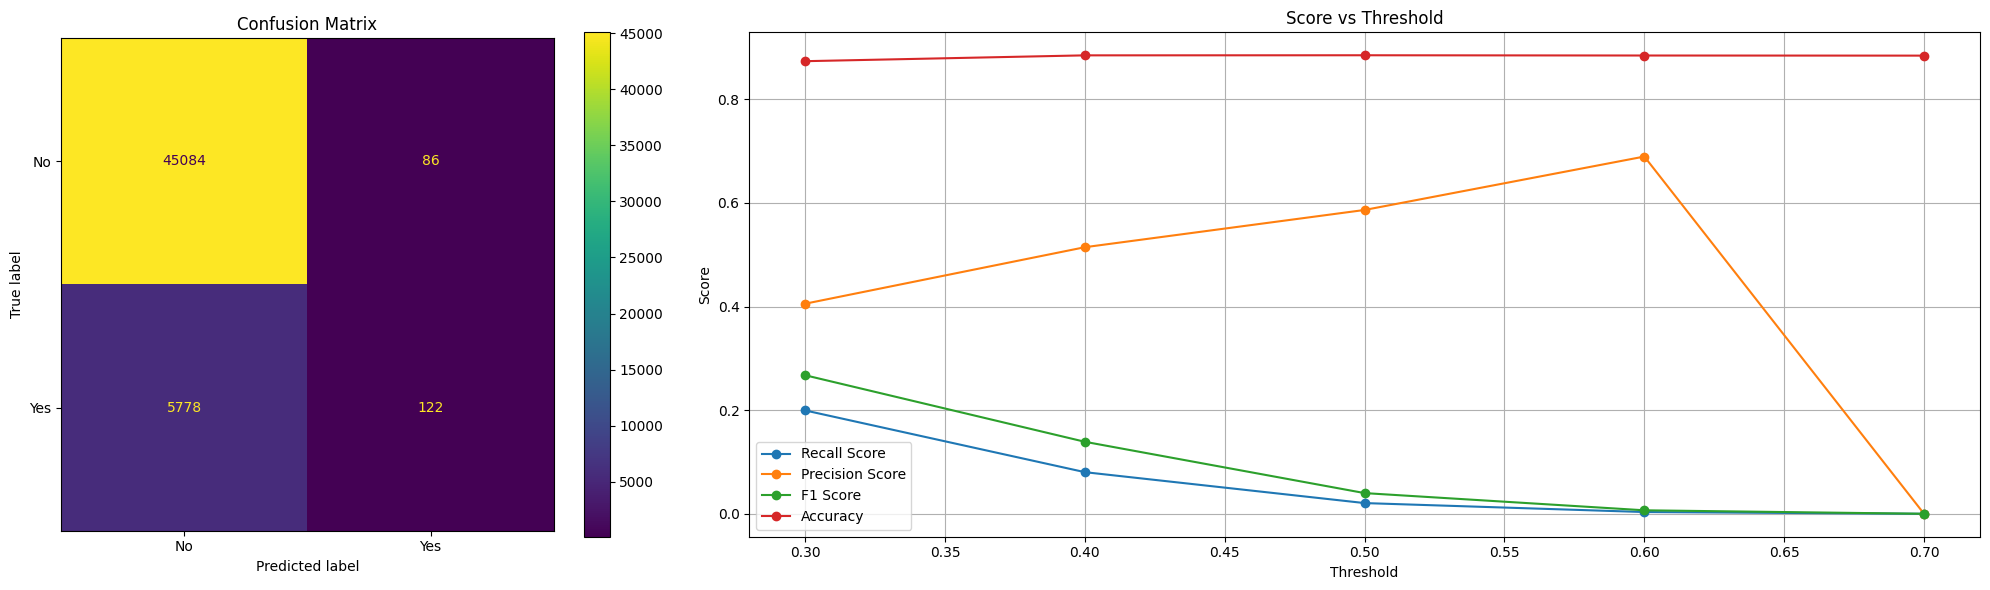

,Score,Percentage
0,Training Accuracy,88.45%
1,Test Accuracy,88.52%
2,Recall Score,0.00%
3,Precision Score,0.00%
4,Accuracy Score,88.45%
5,F1 Score,0.00%
6,ROC AUC Score,50.94%


In [46]:
scores_df, threshold_df = print_evaluation(classifier, X_train, y_train, X_test, y_test)
scores_df

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>5. GridSearhCV</h2>
</div>

In [47]:
params = [
    {     
        "classifier__C": [0.001, 0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['liblinear'],
    },
    {
        "classifier__C": [ 0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['lbfgs','newton-cg', 'newton-cholesky']
    },
    {
        "classifier__C": [0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        "classifier__C": [0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['lbfgs','newton-cg', 'newton-cholesky']
    }
]

In [48]:
cv = GridSearchCV(classifier, params, cv=5, n_jobs=-1, verbose=True, scoring=make_scorer(fbeta_score, beta=2, pos_label=1));

In [49]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 66 candidates, totalling 330 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pca', PCA(n_components=19)),
                                       ('classifier',
                                        LogisticRegression(C=0.01,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid=[{'classifier__C': [0.001, 0.01, 0.1, 10, 100],
                          'classifier__penalty': ['l1', 'l2'],
                          'classifier__solver': ['liblinear']},
                         {'classifier__C': [0.01, 0.1, 10, 100],
                          'classifier__penalty': ['l1', 'l2'],
                          'classifier__so...',
                                                 'newton-cholesky']},
                         {'classifier__C': [0.01, 0.1, 10, 100],
                          'classifier__penalty': ['l1', 'l2'],
                          'classifier__solver': ['liblinear']},
                         {'classifier__C': [0.01, 0.1, 10, 100],
                          'classifier__penalty': ['l1', 'l2'],
                          'classifier__solver': ['lbfgs', 'newton-cg',
                                                 'newton-cholesky']}],
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
             verbose=True)

In [50]:
print("Best Parameters:", cv.best_params_)
print("Best CV Score:", cv.best_score_)

Best Parameters: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV Score: 0.0323030076343918


In [51]:
model = cv.best_estimator_
model

Pipeline(steps=[('pca', PCA(n_components=19)),
                ('classifier',
                 LogisticRegression(C=100, penalty='l1', random_state=42,
                                    solver='liblinear'))])

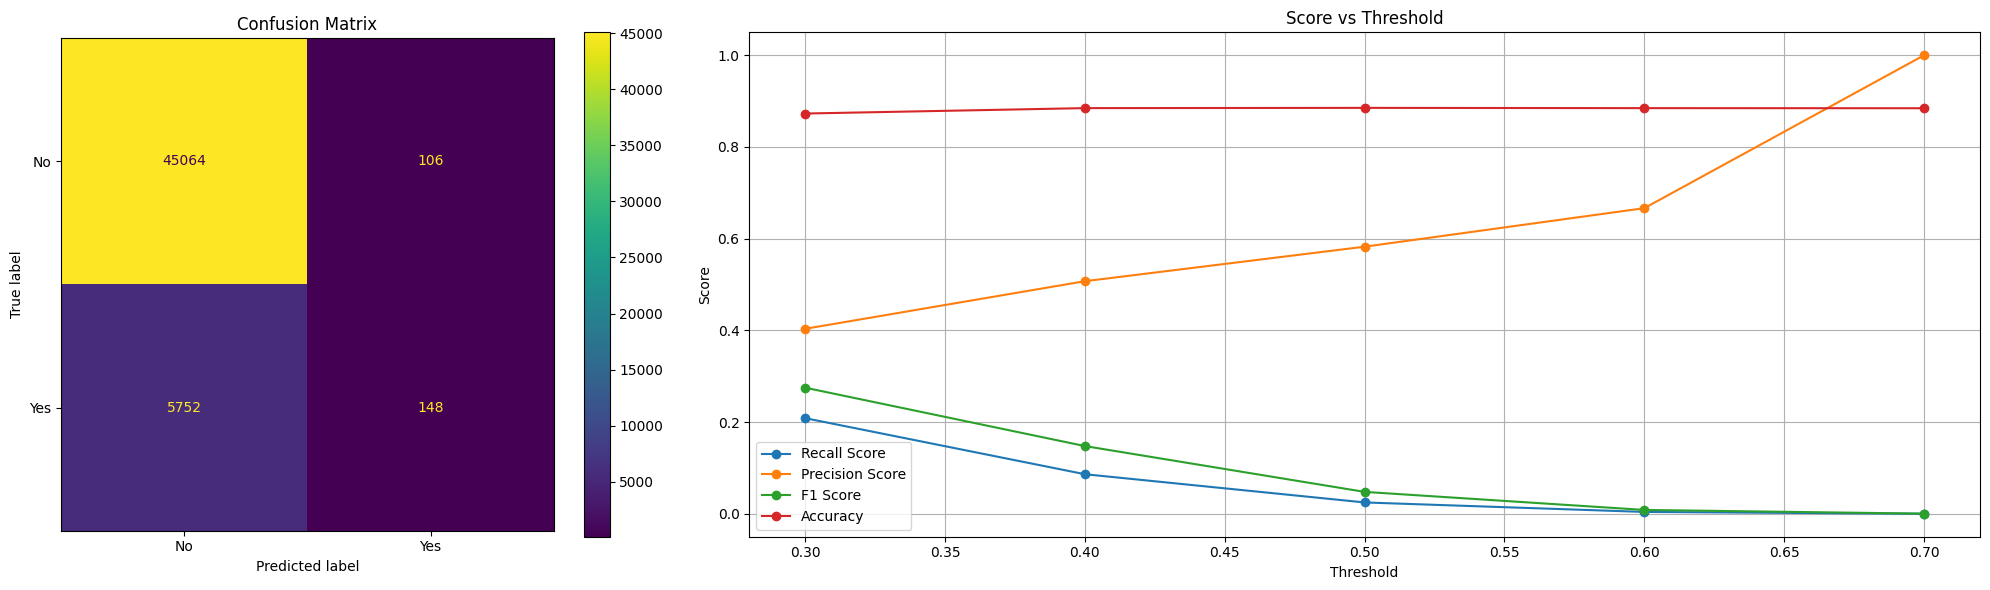

,Score,Percentage
0,Training Accuracy,88.44%
1,Test Accuracy,88.53%
2,Recall Score,0.03%
3,Precision Score,100.00%
4,Accuracy Score,88.45%
5,F1 Score,0.07%
6,ROC AUC Score,51.14%


In [52]:
scores_df, threshold_df = print_evaluation(model, X_train, y_train, X_test, y_test)
scores_df

In [53]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.209,0.404,0.275,0.873
0.400,0.087,0.507,0.148,0.885
0.500,0.025,0.583,0.048,0.885
0.600,0.004,0.667,0.009,0.885
0.700,0.000,1.000,0.001,0.885
